<a href="https://www.kaggle.com/code/sonawanelalitsunil/bmw-car-sales-classification-ml-100?scriptVersionId=255731581" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bmw-car-sales-dataset/BMW_Car_Sales_Classification.csv


## Title:
Car Sales Classification

## Description:
This dataset contains information about BMW car listings, including attributes such as model, year of manufacture, mileage, fuel type, transmission, engine size, and price. It is intended for building classification models to predict categorical outcomes — for example, whether a car falls into a specific sales category (e.g., budget, mid-range, premium) based on its features. Such analysis can help automotive dealers, data analysts, and machine learning practitioners identify trends in BMW sales, optimize pricing strategies, and improve customer targeting. The dataset can also be used for exploratory data analysis (EDA), feature engineering, and training classification algorithms like decision trees, random forests, and gradient boosting models.

## Import Dataset

In [2]:
df = pd.read_csv("/kaggle/input/bmw-car-sales-dataset/BMW_Car_Sales_Classification.csv")

In [3]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [4]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [6]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [7]:
df.dtypes

Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object

In [8]:
df.shape

(50000, 11)

In [9]:
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

## Data visualizations

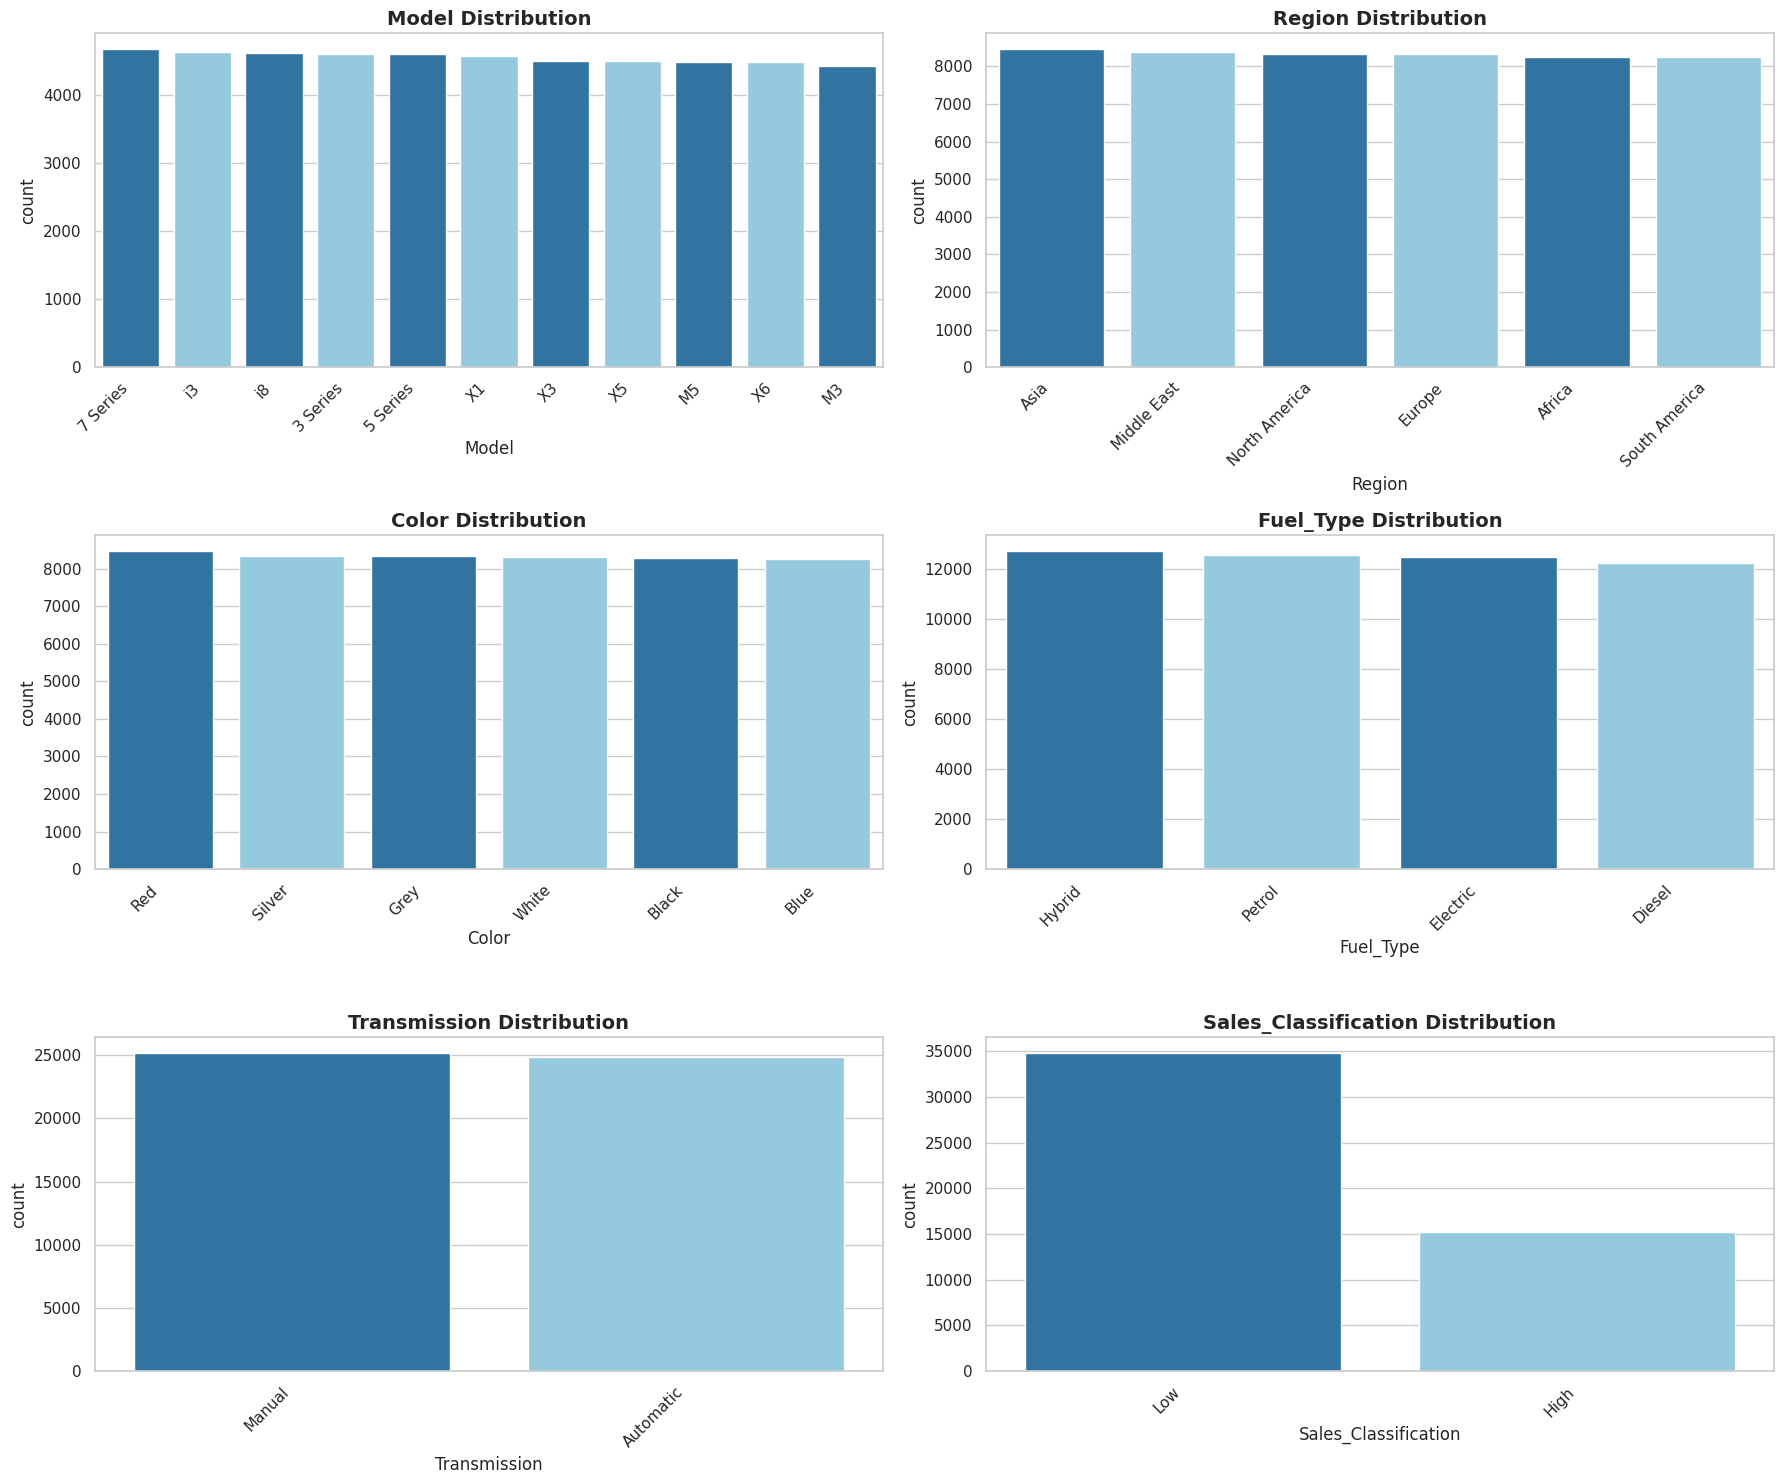

In [12]:
# Set style & palette
sns.set_theme(style="whitegrid")
custom_palette = ["#1f77b4", "#87CEEB"]  # Dark Blue, Sky Blue

# =============================
# 1. Overview of categorical features
# =============================
categorical_cols = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, palette=custom_palette, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

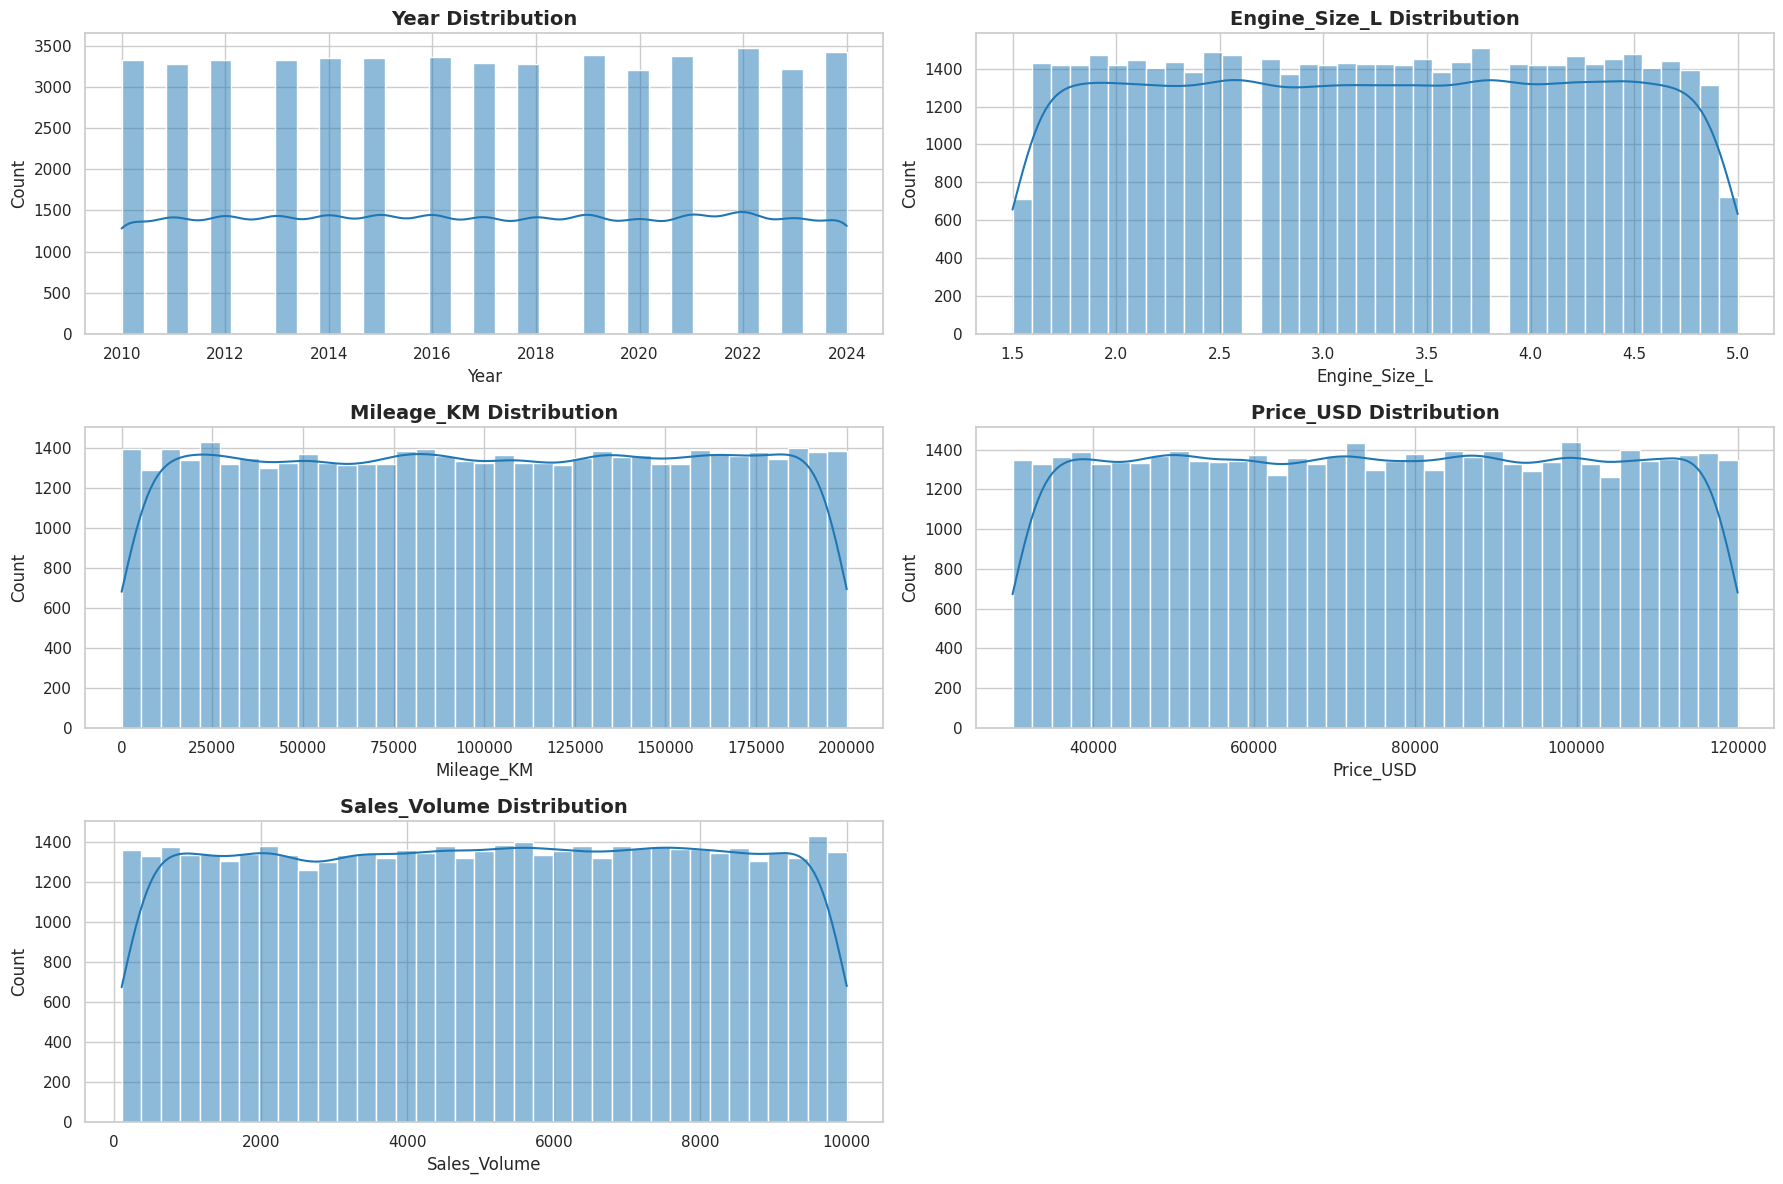

In [13]:
numerical_cols = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, color=custom_palette[0])
    plt.title(f"{col} Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


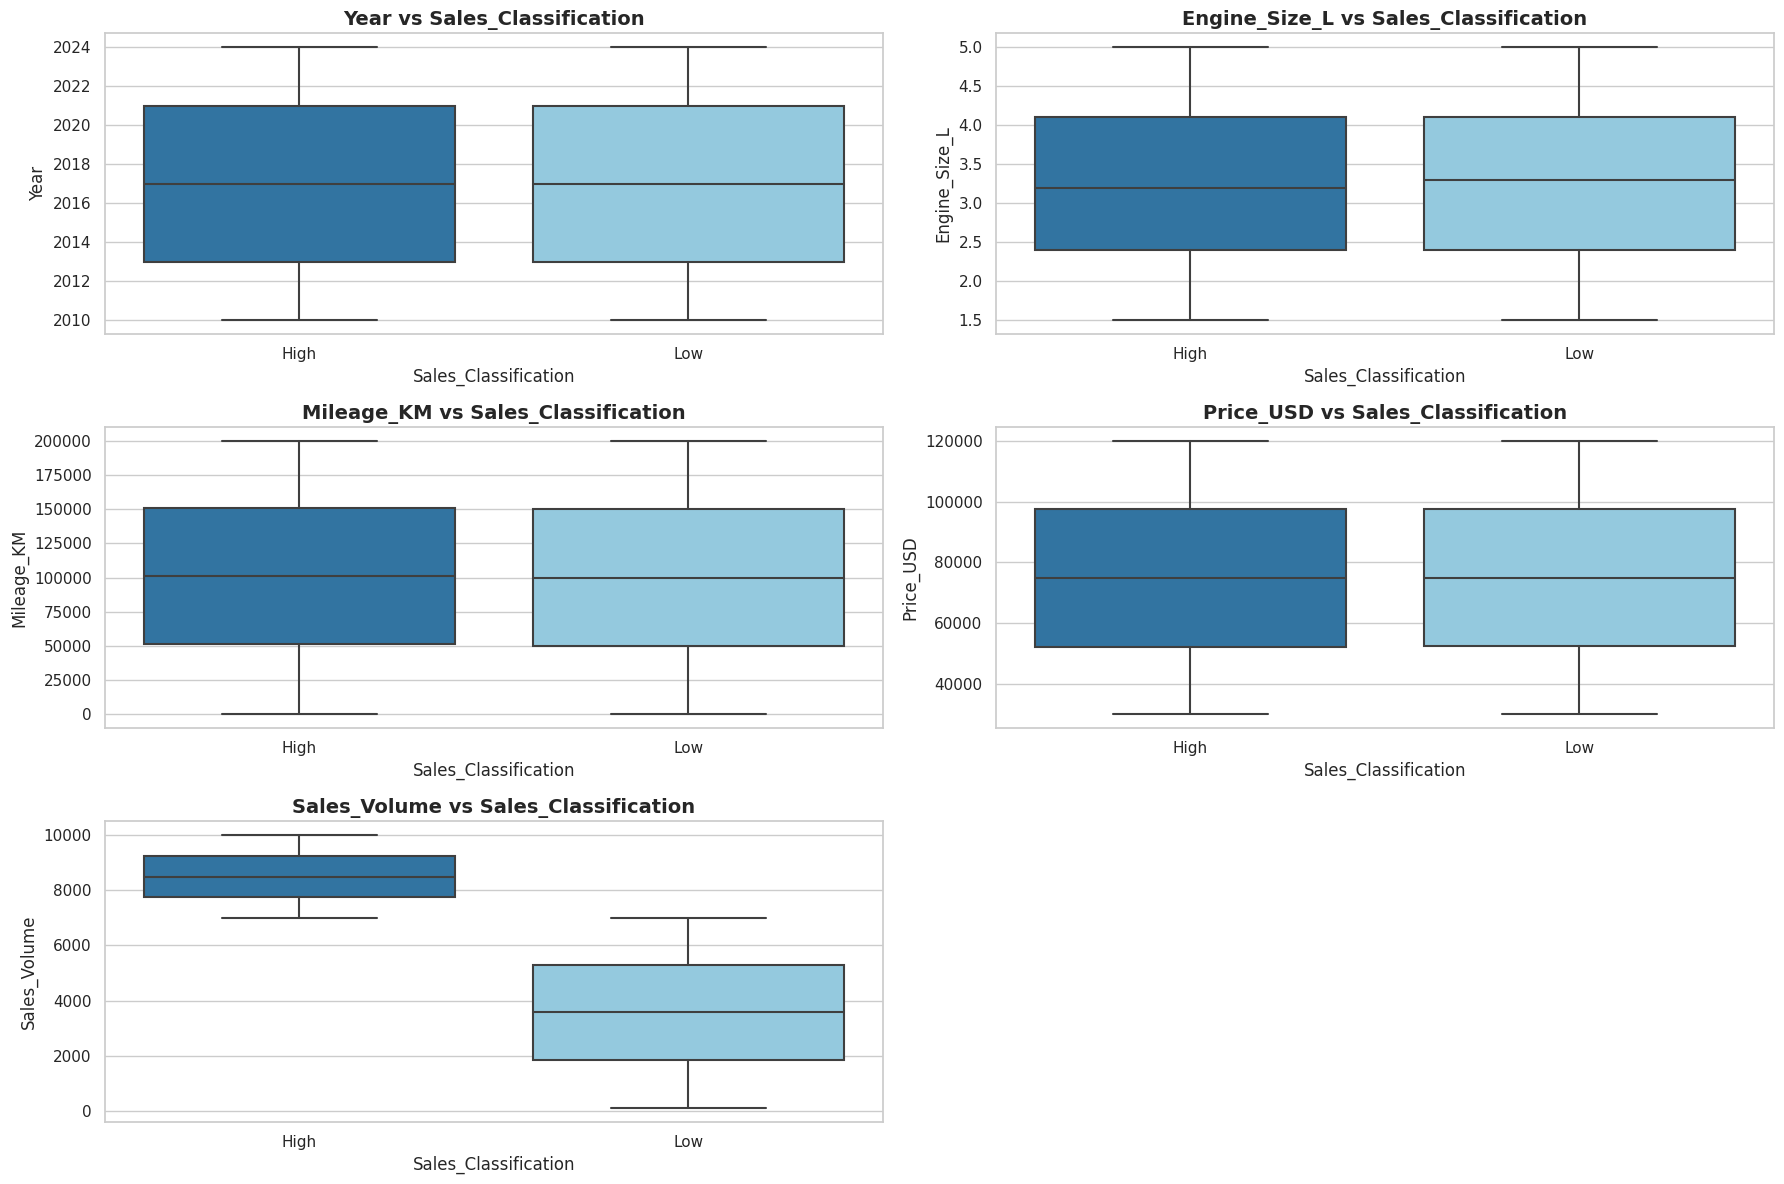

In [14]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, x="Sales_Classification", y=col, palette=custom_palette)
    plt.title(f"{col} vs Sales_Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

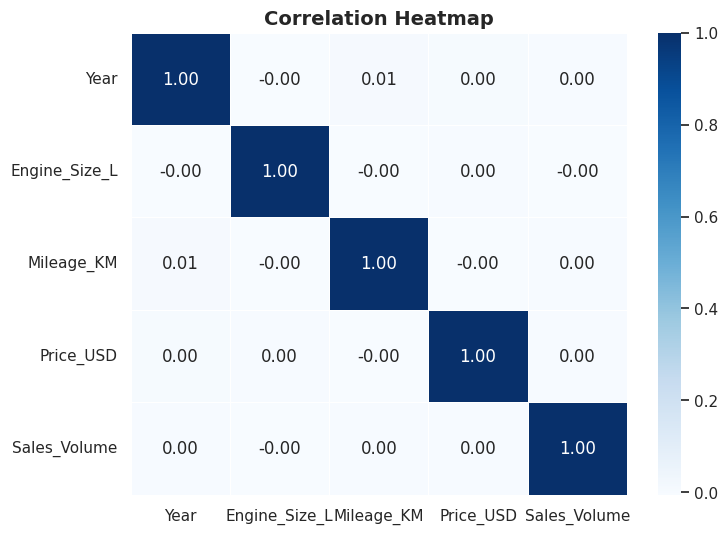

In [15]:
plt.figure(figsize=(8, 6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()


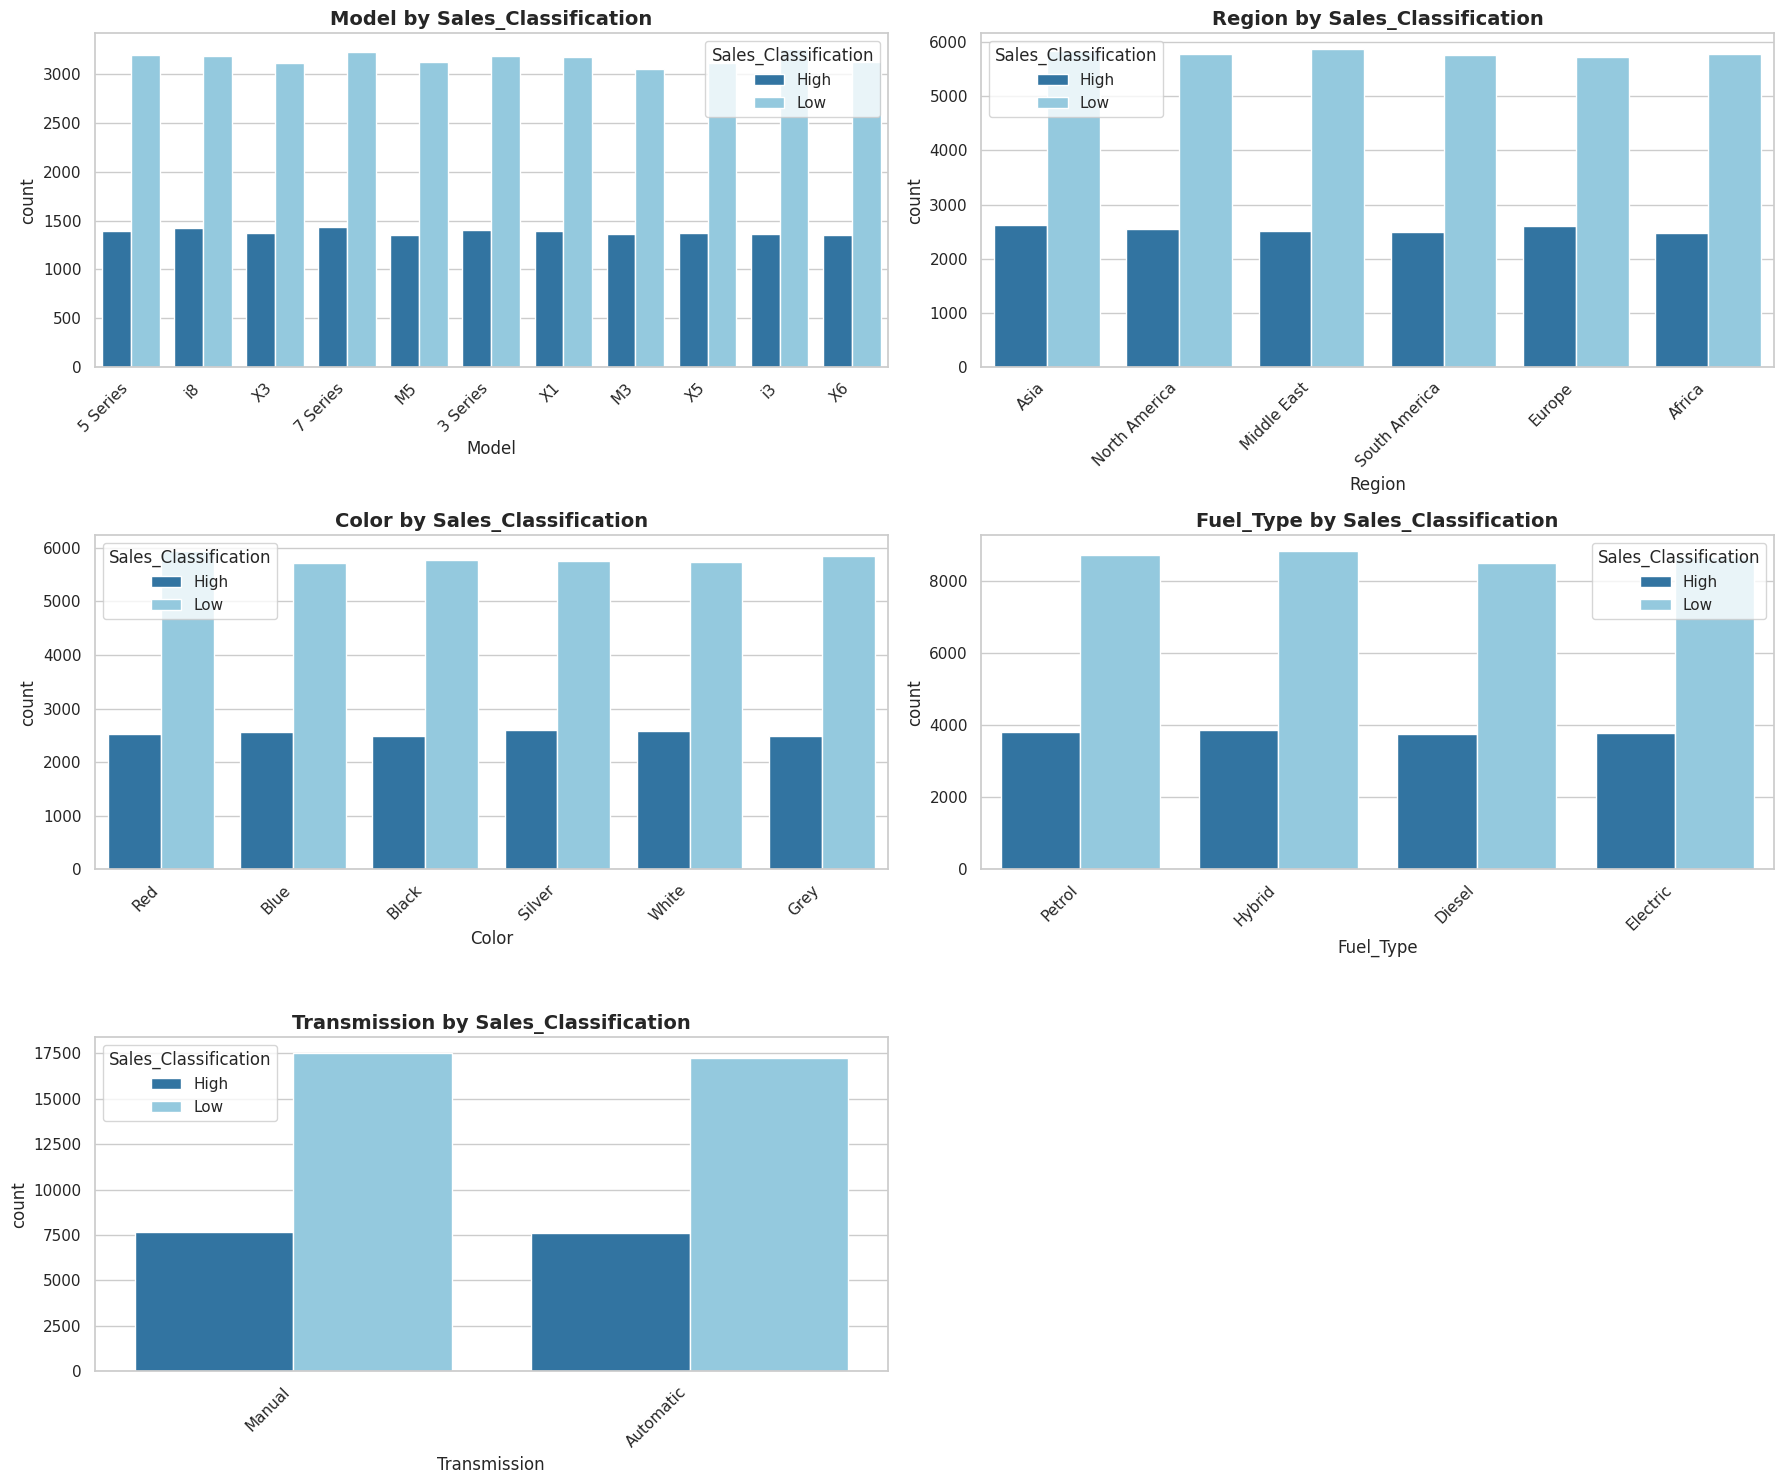

In [16]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols[:-1], 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue="Sales_Classification", palette=custom_palette)
    plt.title(f"{col} by Sales_Classification", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [18]:
# 2. Encode categorical columns
label_encoders = {}
for col in ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store encoder for possible inverse transform

# 3. Define features and target
X = df.drop(columns=['Sales_Classification'])
y = df['Sales_Classification']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
# 5. Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [20]:
# 6. Train & evaluate models
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # percentage
    accuracies[name] = round(acc, 2)

In [21]:
# 7. Show results
print("Model Accuracies (%):")
for name, acc in accuracies.items():
    print(f"{name}: {acc}%")


Model Accuracies (%):
Logistic Regression: 99.9%
Decision Tree: 100.0%
Random Forest: 100.0%
Naive Bayes: 99.96%
Support Vector Machine: 99.58%
K-Nearest Neighbors: 95.77%


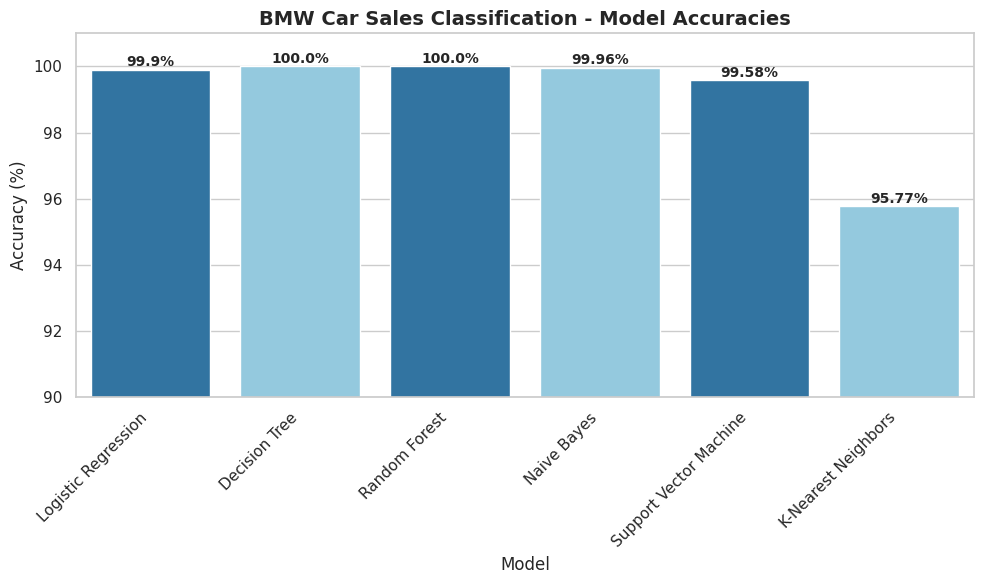

In [22]:
# Given accuracies
accuracies = {
    "Logistic Regression": 99.9,
    "Decision Tree": 100.0,
    "Random Forest": 100.0,
    "Naive Bayes": 99.96,
    "Support Vector Machine": 99.58,
    "K-Nearest Neighbors": 95.77
}

# Convert to DataFrame
acc_df = pd.DataFrame(list(accuracies.items()), columns=["Model", "Accuracy"])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=acc_df, x="Model", y="Accuracy", palette=["#1f77b4", "#87CEEB"])
plt.title("BMW Car Sales Classification - Model Accuracies", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.ylim(90, 101)  # zoom in to highlight high scores
plt.xticks(rotation=45, ha='right')
for i, acc in enumerate(acc_df["Accuracy"]):
    plt.text(i, acc + 0.1, f"{acc}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Thank you...pls upvote